In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("datapackage.json")
#dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-30.zip")
trails = Trails(dp, interpolate_annual=True)

#methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

/Users/romain/micromamba/envs/trails/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Loading matrices from data package          [1/3]
Loading indices from data package           [2/3]
Interpolating matrices to annual resolution [3/3]


In [2]:
ref_year = 2050

trails.lca(
    start_year=ref_year,
    start_act_idx=13,
    #start_act_idx=27826,
    methods=methods,
    max_depth=6,
    return_provenance=True,
    show_progress=True,
    min_amount=1e-18,
    debug=True
)

Temporal LCA: solve years: 100%|█████████████| 55/55 [00:00<00:00, 601.89year/s]


In [3]:
ref_year = 2050
trails.static_lca(
    year=ref_year,
    act_idx=13,
    methods=methods,
)

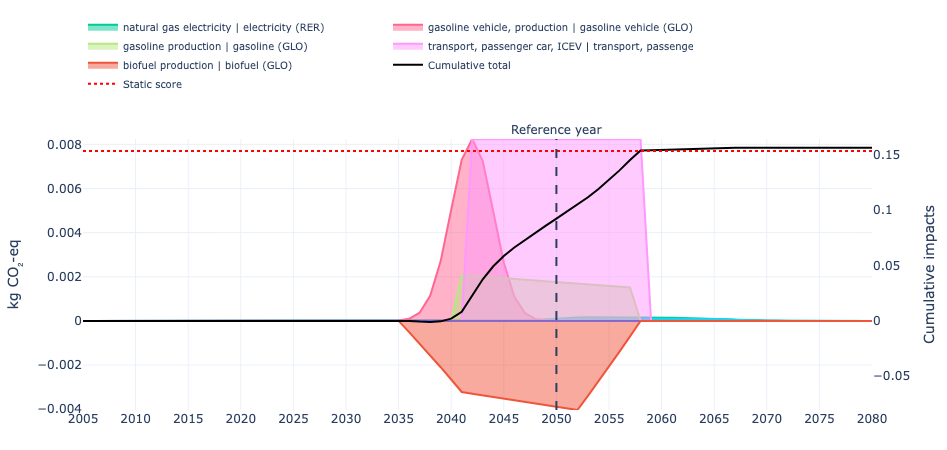

In [6]:
fig = plot_temporal_scores(
    results_by_year=trails.characterized_inventory,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [7]:
ref_year = 2050

trails.lca(
    start_year=ref_year,
    start_act_idx=2,
    methods=methods,
    max_depth=6,
    return_provenance=True,
    show_progress=True,
    min_amount=1e-18,
    debug=True
)

Temporal LCA: solve years: 100%|█████████████| 61/61 [00:00<00:00, 602.34year/s]


In [8]:
ref_year = 2050
trails.static_lca(
    year=ref_year,
    act_idx=2,
    methods=methods,
)

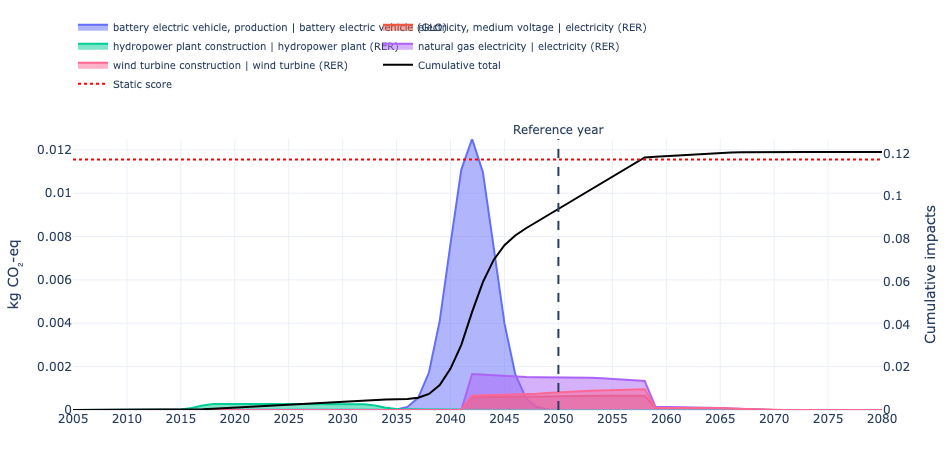

In [9]:
fig = plot_temporal_scores(
    results_by_year=trails.characterized_inventory,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [9]:
from trails.plotting import plot_traversal_grid_flow
edges_by_depth = trails.collect_traversal_edges(
    start_year=2050,
    start_act_idx=13,
    amount=1.0,
    max_depth=5,
    min_amount=1e-18,
)

fig = plot_traversal_grid_flow(
    edges_by_depth=edges_by_depth,
    trails=trails,
    depths=None,                 
    include_all_activities=True,
    title="Traversal flows by depth",
    dot_size=5,
)

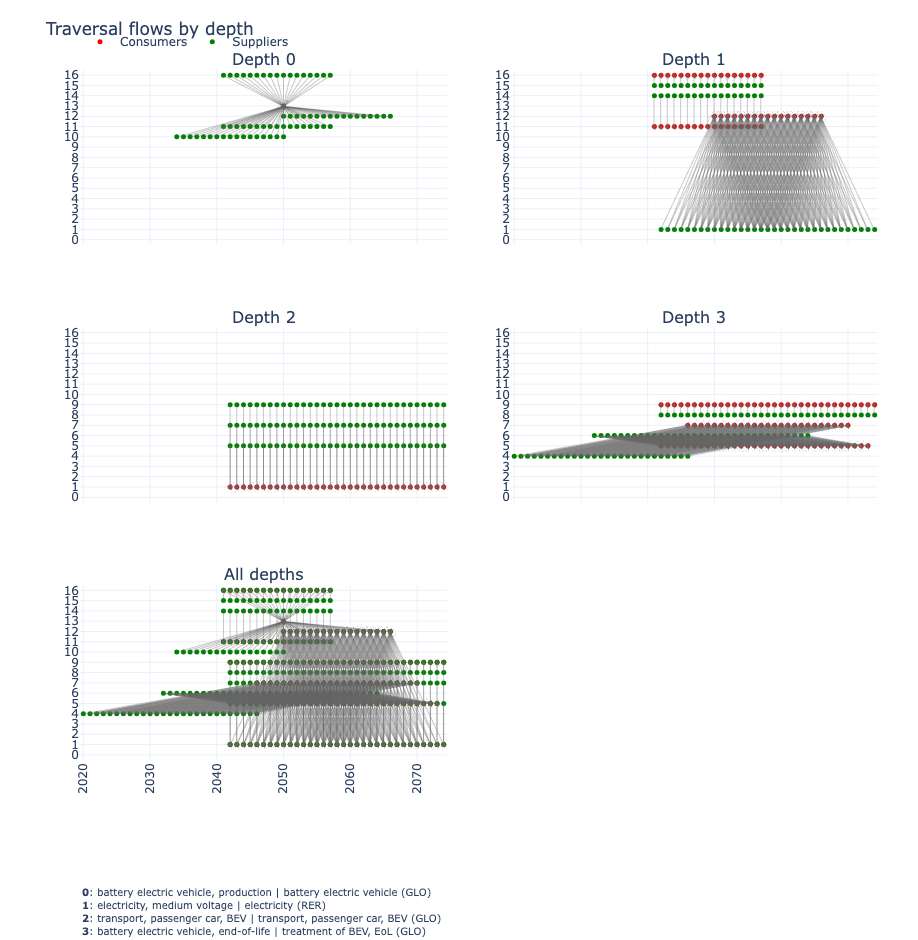

In [10]:
fig